In [145]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import numpy as np

df = pd.read_csv("stores.csv")
df.head()

,Store Number,AreaStore,Property,Type,Old/New,Checkout Number,Revenue
0,1,2100.0,Owned,Hyper,New,6.0,"45,072,000"
1,2,1290.0,Cooperate,Extra,New,5.0,"7,416,000"
2,3,500.0,Rental,Express,New,NaN,"8,592,000"
3,4,2000.0,Owned,Hyper,New,9.0,"48,415,500"
4,5,220.0,Rental,Express,Old,2.0,"3,345,500"


In [146]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118 entries, 0 to 117
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Store Number     118 non-null    int64  
 1   AreaStore        118 non-null    float64
 2   Property         118 non-null    object 
 3   Type             118 non-null    object 
 4   Old/New          118 non-null    object 
 5   Checkout Number  106 non-null    float64
 6   Revenue          118 non-null    object 
dtypes: float64(2), int64(1), object(4)
memory usage: 6.6+ KB


In [147]:
df['Revenue'] = pd.to_numeric(df['Revenue'].str.replace(',',''))
df['Checkout Number'] = df['Checkout Number'].fillna(df['Checkout Number'].median())
df['Property'] = df['Property'].str.strip()



In [148]:
df['Old/New'] = df['Old/New'].str.strip().map({'Old':1,'New':0})

In [149]:
df = pd.get_dummies(df, columns=['Property','Type'],dtype=int)

In [150]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118 entries, 0 to 117
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Store Number               118 non-null    int64  
 1   AreaStore                  118 non-null    float64
 2   Old/New                    118 non-null    int64  
 3   Checkout Number            118 non-null    float64
 4   Revenue                    118 non-null    int64  
 5   Property_Cooperate         118 non-null    int64  
 6   Property_Owned             118 non-null    int64  
 7   Property_Rental            118 non-null    int64  
 8   Property_Rental/Cooperate  118 non-null    int64  
 9   Type_Express               118 non-null    int64  
 10  Type_Extra                 118 non-null    int64  
 11  Type_Hyper                 118 non-null    int64  
dtypes: float64(2), int64(10)
memory usage: 11.2 KB


In [151]:
df.head()

,Store Number,AreaStore,Old/New,Checkout Number,Revenue,Property_Cooperate,Property_Owned,Property_Rental,Property_Rental/Cooperate,Type_Express,Type_Extra,Type_Hyper
0,1,2100.0,0,6.0,45072000,0,1,0,0,0,0,1
1,2,1290.0,0,5.0,7416000,1,0,0,0,0,1,0
2,3,500.0,0,4.0,8592000,0,0,1,0,1,0,0
3,4,2000.0,0,9.0,48415500,0,1,0,0,0,0,1
4,5,220.0,1,2.0,3345500,0,0,1,0,1,0,0


In [152]:
sns.set_style('darkgrid')
plt.rcParams['font.size'] = 14
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.facecolor'] = '#00000000'

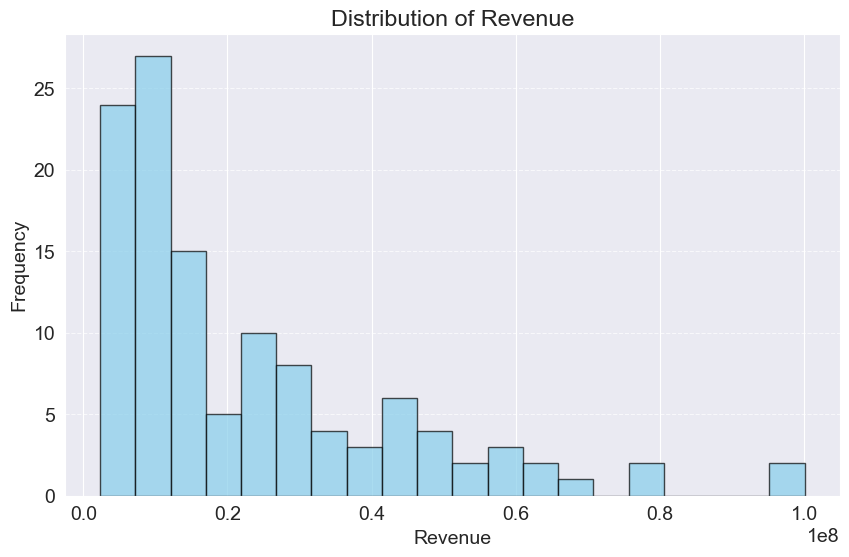

In [153]:
plt.figure(figsize=(10, 6))
plt.hist(df['Revenue'], bins=20, color='skyblue', edgecolor='black', alpha=0.7)

# Add labels and title
plt.title('Distribution of Revenue')
plt.xlabel('Revenue')
plt.ylabel('Frequency')

# Show the plot
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

<Axes: xlabel='AreaStore'>

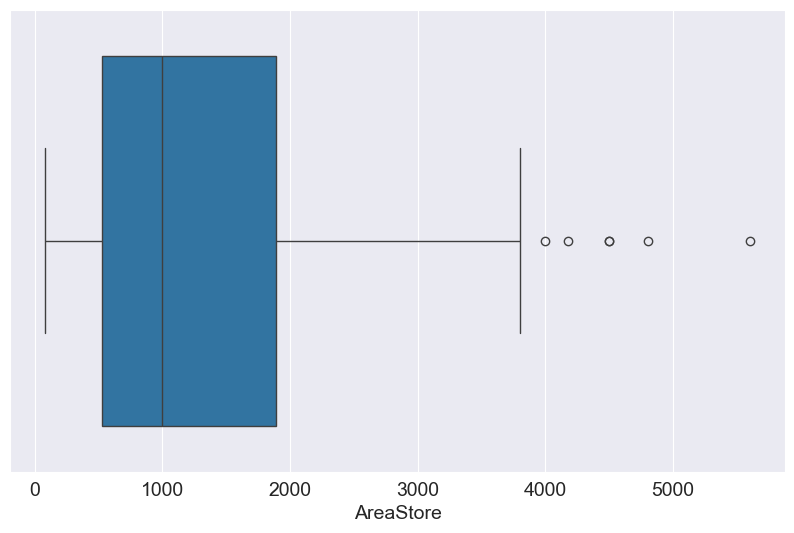

In [154]:

sns.boxplot(x=df['AreaStore'])

In [155]:
# Drop ID
df.drop('Store Number', axis=1, inplace=True)

# Log target
y = np.log1p(df['Revenue'])

# Features
X = df.drop('Revenue', axis=1)

In [162]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [163]:
x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [175]:
model = RandomForestRegressor(random_state=42,max_depth=10,n_estimators=200,min_samples_split=5)

In [176]:
model.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [177]:
pred = model.predict(x_test)

In [178]:
print("Mean Absolute Error :", mean_absolute_error(y_test, pred))
print("Mean Squared Error :", mean_squared_error(y_test, pred))
print("Root Mean Squared Error :", np.sqrt(mean_squared_error(y_test, pred)))
print("R2 Score :", r2_score(y_test, pred))

Mean Absolute Error : 0.5522432400403373
Mean Squared Error : 0.5167221350417379
Root Mean Squared Error : 0.7188338716572403
R2 Score : 0.42066517739029563


In [160]:
importances = model.feature_importances_

# pair with column names
feature_importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': importances
})

# sort by importance
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)

print(feature_importance_df)

                     feature  importance
0                  AreaStore    0.614844
2            Checkout Number    0.237741
4             Property_Owned    0.062380
6  Property_Rental/Cooperate    0.027944
1                    Old/New    0.019654
5            Property_Rental    0.010768
3         Property_Cooperate    0.009220
8                 Type_Extra    0.006866
9                 Type_Hyper    0.005986
7               Type_Express    0.004597


<Axes: xlabel='importance', ylabel='feature'>

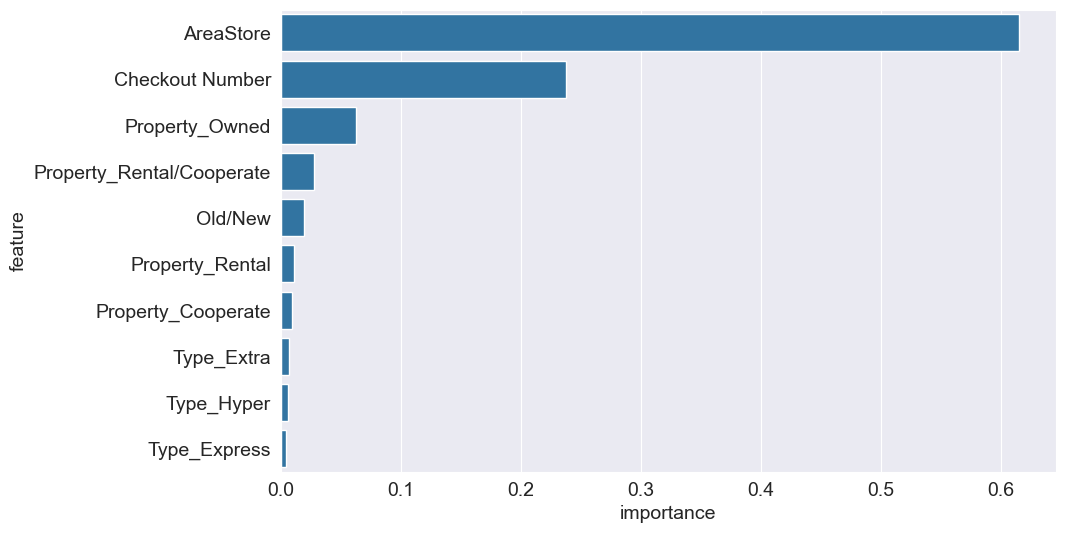

In [161]:
sns.barplot(y="feature", x="importance", data=feature_importance_df, orient='h')

In [171]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

# 1. Define the grid of parameters to test
param_grid = {
    'n_estimators': [50, 100, 200],      # Number of trees
    'max_depth': [None, 10, 20],         # Maximum depth of the tree
    'min_samples_split': [2, 5, 10]      # Minimum number of samples required to split a node
}

# 2. Initialize the Grid Search model
print("Starting Grid Search... this may take a few seconds.")
grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,               # 5-fold cross-validation
    scoring='r2',       # We want to optimize for the best R-squared score
    n_jobs=-1           # Use all available CPU cores to speed it up
)

# 3. Fit it to the training data
grid_search.fit(x_train, y_train)

# 4. Print the best parameters it found
print("\n--- Tuning Complete ---")
print("Best Parameters Found:")
print(grid_search.best_params_)

# 5. Extract the optimized model
best_rf_model = grid_search.best_estimator_


Starting Grid Search... this may take a few seconds.

--- Tuning Complete ---
Best Parameters Found:
{'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}


In [174]:
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

# 1. Use the best model from the grid search to make predictions on the unseen test data
y_pred_log = best_rf_model.predict(x_test)

# 2. Check the R2 score in log space (to compare against your baseline 0.436)
new_r2 = r2_score(y_test, y_pred_log)
print(f"Optimized R2 Score: {new_r2:.4f}")

# 3. Convert predictions and actuals back to REAL DOLLARS
y_pred_dollars = np.expm1(y_pred_log)
y_test_dollars = np.expm1(y_test)

# 4. Calculate the real-world Mean Absolute Error
real_mae = mean_absolute_error(y_test_dollars, y_pred_dollars)

print(f"Real-World MAE: ${real_mae:,.2f}")


Optimized R2 Score: 0.4207
Real-World MAE: $8,973,871.09
